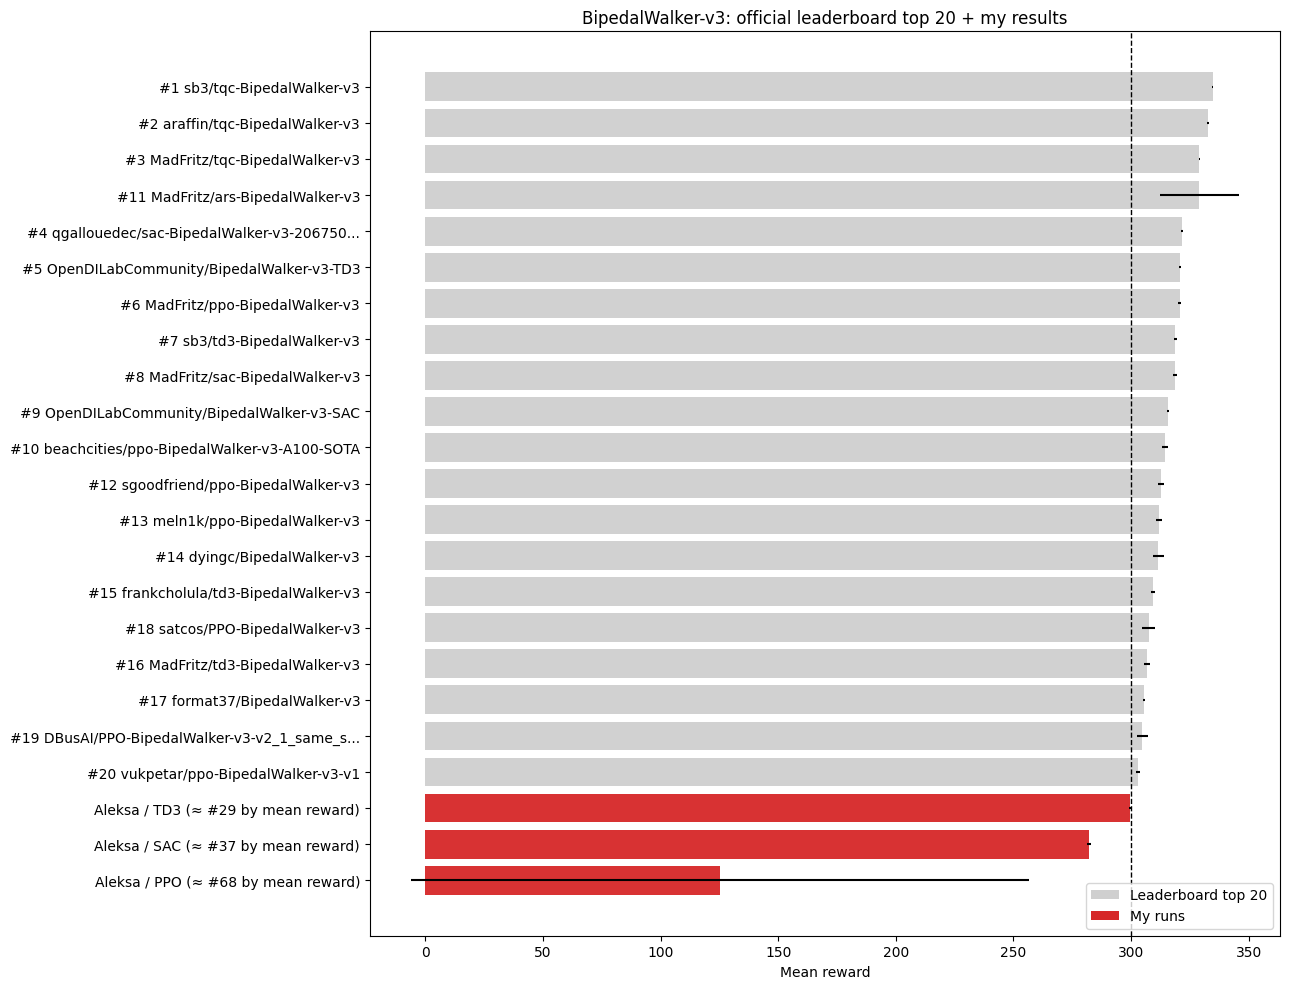

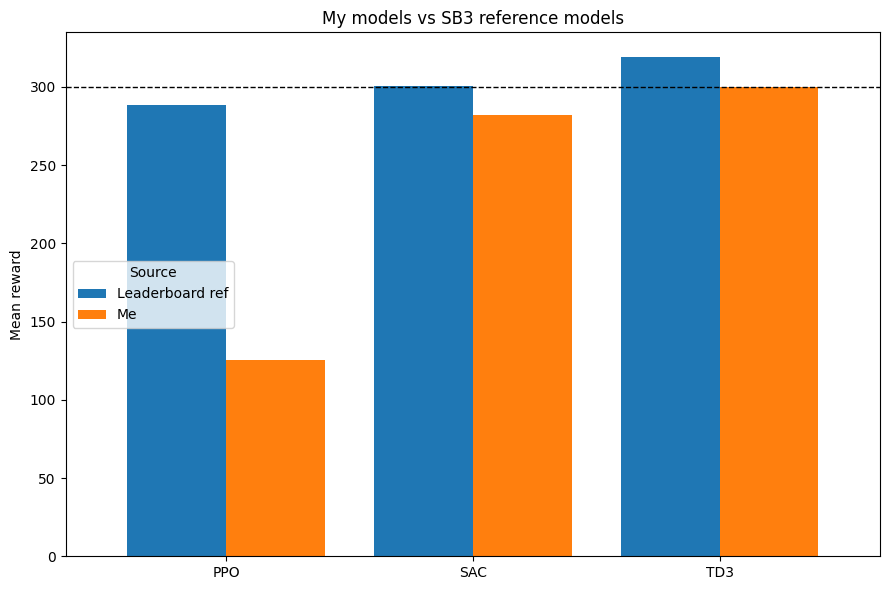


=== My approximate positions by mean reward ===
Aleksa / TD3: mean=299.54, std=0.46, approx_rank_by_mean=29
Aleksa / SAC: mean=282.08, std=0.91, approx_rank_by_mean=37
Aleksa / PPO: mean=125.28, std=131.29, approx_rank_by_mean=68


In [1]:
# pip install pandas matplotlib

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

LEADERBOARD_URL = (
    "https://huggingface.co/datasets/"
    "huggingface-projects/drlc-leaderboard-data/"
    "resolve/main/BipedalWalker-v3.csv?download=true"
)

MY_RESULTS = {
    "Aleksa / TD3": {"algo": "TD3", "mean": 299.54, "std": 0.46},
    "Aleksa / SAC": {"algo": "SAC", "mean": 282.08, "std": 0.91},
    "Aleksa / PPO": {"algo": "PPO", "mean": 125.28, "std": 131.29},
}

HF_REF_MODELS = {
    "TD3": "sb3/td3-BipedalWalker-v3",
    "SAC": "sb3/sac-BipedalWalker-v3",
    "PPO": "sb3/ppo-BipedalWalker-v3",
}


def short_label(text: str, max_len: int = 42) -> str:
    return text if len(text) <= max_len else text[: max_len - 3] + "..."


# ucitati leaderboard
df = pd.read_csv(LEADERBOARD_URL)
df.columns = [c.strip() for c in df.columns]

for col in ["Ranking", "Mean Reward", "Std Reward", "Results"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# =========
# chart 1: official leaderboard top 20 + tvoji rezultati
# =========
top20 = (
    df.sort_values("Ranking")
      .head(20)[["Ranking", "Model", "Mean Reward", "Std Reward"]]
      .copy()
)

top20["Label"] = top20.apply(
    lambda r: f'#{int(r["Ranking"])} {short_label(r["Model"])}', axis=1
)
top20["Source"] = "Leaderboard"

my_rows = []
for name, vals in MY_RESULTS.items():
    rank_by_mean = int((df["Mean Reward"] > vals["mean"]).sum() + 1)
    my_rows.append(
        {
            "Ranking": None,
            "Model": name,
            "Mean Reward": vals["mean"],
            "Std Reward": vals["std"],
            "Label": f"{name} (≈ #{rank_by_mean} by mean reward)",
            "Source": "Me",
        }
    )

my_df = pd.DataFrame(my_rows)

plot_df = pd.concat([top20, my_df], ignore_index=True)
plot_df = plot_df.sort_values("Mean Reward", ascending=True)

colors = ["#cfcfcf" if s == "Leaderboard" else "#d62728" for s in plot_df["Source"]]

plt.figure(figsize=(13, 10))
plt.barh(
    plot_df["Label"],
    plot_df["Mean Reward"],
    xerr=plot_df["Std Reward"],
    color=colors,
    alpha=0.95,
)
plt.axvline(300, linestyle="--", linewidth=1, color="black", label="Solved ≈ 300")
plt.xlabel("Mean reward")
plt.ylabel("")
plt.title("BipedalWalker-v3: official leaderboard top 20 + my results")
plt.legend(
    handles=[
        Patch(facecolor="#cfcfcf", label="Leaderboard top 20"),
        Patch(facecolor="#d62728", label="My runs"),
    ],
    loc="lower right",
)
plt.tight_layout()
plt.savefig("bipedalwalker_top20_vs_me.png", dpi=200, bbox_inches="tight")
plt.show()

# =========
# chart 2: moj PPO/SAC/TD3 vs SB3 reference PPO/SAC/TD3
# =========
compare_rows = []

for algo, model_name in HF_REF_MODELS.items():
    hf_row = df[df["Model"].str.lower() == model_name.lower()]
    if hf_row.empty:
        continue

    hf_row = hf_row.iloc[0]

    my_name = f"Aleksa / {algo}"
    my_vals = MY_RESULTS[my_name]

    compare_rows.append(
        {
            "Algorithm": algo,
            "Source": "Leaderboard ref",
            "Mean Reward": float(hf_row["Mean Reward"]),
        }
    )
    compare_rows.append(
        {
            "Algorithm": algo,
            "Source": "Me",
            "Mean Reward": my_vals["mean"],
        }
    )

cmp_df = pd.DataFrame(compare_rows)
pivot = cmp_df.pivot(index="Algorithm", columns="Source", values="Mean Reward")
pivot = pivot.reindex(["PPO", "SAC", "TD3"])

ax = pivot.plot(kind="bar", figsize=(9, 6), width=0.8)
ax.axhline(300, linestyle="--", linewidth=1, color="black")
ax.set_title("My models vs SB3 reference models")
ax.set_ylabel("Mean reward")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("bipedalwalker_me_vs_sb3_refs.png", dpi=200, bbox_inches="tight")
plt.show()

# =========
# mali pregled u terminalu
# =========
print("\n=== My approximate positions by mean reward ===")
for name, vals in MY_RESULTS.items():
    rank_by_mean = int((df["Mean Reward"] > vals["mean"]).sum() + 1)
    print(f"{name}: mean={vals['mean']:.2f}, std={vals['std']:.2f}, approx_rank_by_mean={rank_by_mean}")

In [3]:
import math
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt


# ============================================================
# Podesiti putanju do checkpoint-a
# ============================================================
POLICY_PATH = "policy.pth"
OUT_DIR = Path("policy_diagnostics")
OUT_DIR.mkdir(exist_ok=True)


# ============================================================
# Učitati state_dict iz SB3 PPO politike
# ============================================================
state_dict = torch.load(POLICY_PATH, map_location="cpu")

# Očekivani ključevi za MlpPolicy / ActorCriticPolicy
W1 = state_dict["mlp_extractor.policy_net.0.weight"]   # (64, 24)
W2 = state_dict["mlp_extractor.policy_net.2.weight"]   # (64, 64)
Wa = state_dict["action_net.weight"]                   # (4, 64)
ba = state_dict["action_net.bias"]                     # (4,)
log_std = state_dict["log_std"]                        # (4,)

# Pretvoriti log_std u std
action_std = torch.exp(log_std).detach().cpu().numpy()

# ============================================================
# Aproksimacija "uticaja observation-a na akcije"
#
# Ideja:
# Ne znamo konkretne aktivacije bez rollout-a, ali možemo napraviti
# grubu statičku procenu koliko svaki observation indeks prolazi
# kroz policy mrežu do svake akcije.
#
# Koristimo apsolutne vrednosti težina:
# influence ~= |Wa| @ |W2| @ |W1|
#
# Rezultat je matrica oblika (4 akcije x 24 observation ulaza).
# Ovo NIJE kauzalni dokaz, ali je vrlo koristan signal.
# ============================================================
effective_influence = torch.abs(Wa) @ torch.abs(W2) @ torch.abs(W1)
effective_influence = effective_influence.detach().cpu().numpy()   # (4, 24)

# Ukupan uticaj svakog observation indeksa na sve akcije
obs_total_influence = effective_influence.sum(axis=0)              # (24,)

# Ukupan uticaj po akciji
action_total_influence = effective_influence.sum(axis=1)           # (4,)

# Top observation indeksi
top_obs_idx = np.argsort(-obs_total_influence)[:10]

print("\n=== Top 10 observation indeksa po uticaju ===")
for rank, idx in enumerate(top_obs_idx, start=1):
    print(f"{rank:>2}. obs_{idx:02d} -> influence={obs_total_influence[idx]:.4f}")

print("\n=== Action std ===")
for i, std in enumerate(action_std):
    print(f"action_{i}: std={std:.4f}")

print("\n=== Action bias ===")
for i, bias in enumerate(ba.detach().cpu().numpy()):
    print(f"action_{i}: bias={bias:.4f}")


# ============================================================
# 1) Grafikon: exploration std po akciji
#
# Ako su std vrednosti niske, politika je prilično "ukočena"
# i manje verovatno izlazi iz lošeg lokalnog optimuma.
# ============================================================
plt.figure(figsize=(8, 4.5))
plt.bar([f"action_{i}" for i in range(len(action_std))], action_std)
plt.title("Policy exploration std per action")
plt.ylabel("std = exp(log_std)")
plt.tight_layout()
plt.savefig(OUT_DIR / "01_action_std.png", dpi=200)
plt.close()


# ============================================================
# 2) Grafikon: ukupan uticaj svakog observation ulaza
#
# Ako nekoliko observation indeksa brutalno dominira,
# politika je verovatno previše uska i oslanja se na mali deo signala.
# ============================================================
plt.figure(figsize=(12, 5))
plt.bar([f"obs_{i}" for i in range(len(obs_total_influence))], obs_total_influence)
plt.title("Total observation influence on policy actions")
plt.ylabel("summed effective influence")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUT_DIR / "02_obs_total_influence.png", dpi=200)
plt.close()


# ============================================================
# 3) Heatmap: observation -> action influence
#
# Ovo pomaže da vidiš da li su neke akcije "zakačene"
# samo za uzak deo observation prostora.
# ============================================================
plt.figure(figsize=(12, 4.5))
plt.imshow(effective_influence, aspect="auto")
plt.colorbar(label="effective influence")
plt.yticks(range(4), [f"action_{i}" for i in range(4)])
plt.xticks(range(24), [f"obs_{i}" for i in range(24)], rotation=45)
plt.title("Observation-to-action influence heatmap")
plt.tight_layout()
plt.savefig(OUT_DIR / "03_obs_action_heatmap.png", dpi=200)
plt.close()


# ============================================================
# 4) Dodatni grafikon: bias i total influence po akciji
#
# Korisno da vidiš da li je neka akcija "pasivna"
# ili ima znatno manji ukupan odziv od ostalih.
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

axes[0].bar([f"action_{i}" for i in range(4)], ba.detach().cpu().numpy())
axes[0].set_title("Action head bias")
axes[0].set_ylabel("bias")

axes[1].bar([f"action_{i}" for i in range(4)], action_total_influence)
axes[1].set_title("Total incoming influence per action")
axes[1].set_ylabel("summed effective influence")

plt.tight_layout()
plt.savefig(OUT_DIR / "04_action_bias_and_influence.png", dpi=200)
plt.close()


print(f"\nGrafikoni su sačuvani u folder: {OUT_DIR.resolve()}")


=== Top 10 observation indeksa po uticaju ===
 1. obs_02 -> influence=35.1659
 2. obs_03 -> influence=27.3344
 3. obs_07 -> influence=24.4860
 4. obs_05 -> influence=24.1535
 5. obs_01 -> influence=23.3395
 6. obs_00 -> influence=20.4051
 7. obs_10 -> influence=20.3390
 8. obs_11 -> influence=17.7761
 9. obs_17 -> influence=15.2882
10. obs_06 -> influence=15.2761

=== Action std ===
action_0: std=0.2605
action_1: std=0.1412
action_2: std=0.1830
action_3: std=0.1292

=== Action bias ===
action_0: bias=0.0625
action_1: bias=0.0589
action_2: bias=-0.0308
action_3: bias=0.0227

Grafikoni su sačuvani u folder: C:\Users\aleks\Desktop\Aleksie kerefeke\Python_Exercise\bipedal-walker-v3\policy_diagnostics
